In [1]:
from datamodel import TradingState, Listing, OrderDepth, Observation, Symbol, Trade, Position, Order
from backtester import Backtester
from typing import Dict, List
from trader import Trader
import matplotlib.pyplot as plt
from visualizer import BacktestingResult
import numpy as np
import json

In [2]:
from data_parser import clean_df, get_group_prices
import pandas as pd
import matplotlib.pyplot as plt
df=get_group_prices(["./data/round_1_data/prices_round_1_day_-2.csv", "./data/round_1_data/prices_round_1_day_-1.csv", "./data/round_1_data/prices_round_1_day_0.csv"])

In [ ]:
df.head()

,index,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,-2,0,INTARIAN_PEPPER_ROOT,9992,17,0,0,0,0,10005,9,10008,17,0,0,9998.5,0.0
1,1,-2,0,ASH_COATED_OSMIUM,0,0,0,0,0,0,10010,25,0,0,0,0,10010.0,0.0
2,2,-2,100,INTARIAN_PEPPER_ROOT,9995,11,9992,16,0,0,10006,11,10008,16,0,0,10000.5,0.0
3,3,-2,100,ASH_COATED_OSMIUM,9992,15,0,0,0,0,10008,15,10011,20,0,0,10000.0,0.0
4,4,-2,200,INTARIAN_PEPPER_ROOT,9995,12,0,0,0,0,10008,20,0,0,0,0,10001.5,0.0


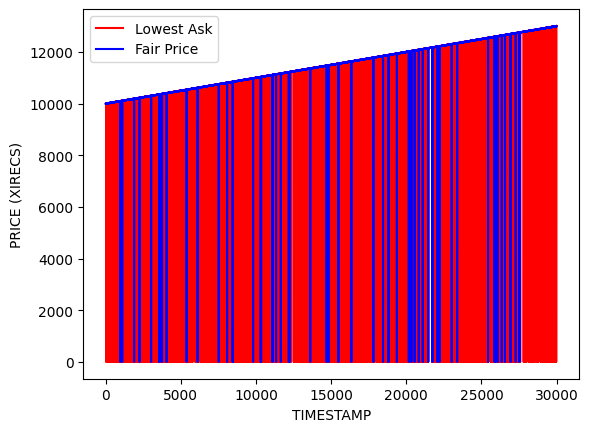

In [3]:
#pepper RESEARCH

pepper_bid_price = df.loc[df['product']=="INTARIAN_PEPPER_ROOT"]["bid_price_1"].to_numpy()
pepper_ask_price = df.loc[df['product']=="INTARIAN_PEPPER_ROOT"]["ask_price_1"].to_numpy()
pepper_mid_price = df.loc[df['product']=="INTARIAN_PEPPER_ROOT"]["mid_price"].to_numpy().astype(float)

#plt.plot([i for i in range(len(pepper_bid_price))], pepper_bid_price, color="green", label="Best Bid")
plt.plot([i for i in range(len(pepper_ask_price))], pepper_ask_price, color="red", label="Lowest Ask")
plt.plot([i for i in range(len(pepper_bid_price))], pepper_mid_price, color="blue", label="Fair Price")
plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

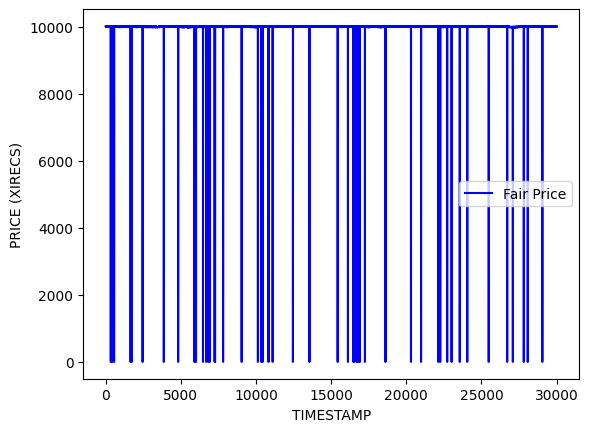

In [4]:
#OSMIUM RESEARCH

osmium_bid_price = df.loc[df['product']=="ASH_COATED_OSMIUM"]["bid_price_1"].to_numpy()
osmium_ask_price = df.loc[df['product']=="ASH_COATED_OSMIUM"]["ask_price_1"].to_numpy()
osmium_mid_price = df.loc[df['product']=="ASH_COATED_OSMIUM"]["mid_price"].to_numpy().astype(float)

#plt.plot([i for i in range(len(osmium_bid_price))], osmium_bid_price, color="green", label="Best Bid")
#plt.plot([i for i in range(len(osmium_bid_price))], osmium_ask_price, color="red", label="Lowest Ask")
plt.plot([i for i in range(len(osmium_bid_price))], osmium_mid_price, color="blue", label="Fair Price")
plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

In [5]:
(osmium_ask_price-osmium_bid_price).mean()

np.float64(16.5184)

In [108]:
new_osmium = []
new_osmium_bids = []
new_osmium_asks = []
for i, ele in enumerate(osmium_mid_price):
    if ele > 0:
        new_osmium.append(osmium_mid_price[i])
        new_osmium_bids.append(osmium_bid_price[i])
        new_osmium_asks.append(osmium_ask_price[i])

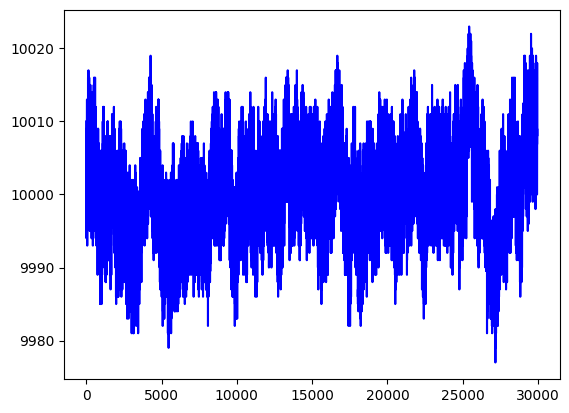

In [109]:
plt.plot(new_osmium, color="blue", label="Fair Price") # Clearly very noisy, so probably pivot to simple MM

In [111]:
(np.array(osmium_bid_price) - np.array(osmium_ask_price)).mean()

np.float64(-16.5184)

(array([1.000e+00, 3.000e+00, 0.000e+00, 1.000e+01, 1.700e+01, 2.200e+01,
        6.800e+01, 6.600e+01, 1.230e+02, 1.460e+02, 3.190e+02, 4.220e+02,
        5.450e+02, 1.380e+03, 1.076e+03, 1.181e+03, 1.816e+03, 1.884e+03,
        1.905e+03, 1.937e+03, 4.433e+03, 2.659e+03, 2.210e+03, 2.105e+03,
        1.349e+03, 1.097e+03, 1.386e+03, 5.060e+02, 3.930e+02, 2.880e+02,
        2.280e+02, 1.340e+02, 9.300e+01, 9.200e+01, 2.200e+01, 1.200e+01,
        1.400e+01, 3.000e+00, 2.000e+00, 4.000e+00]),
 array([ 9977.  ,  9978.15,  9979.3 ,  9980.45,  9981.6 ,  9982.75,
         9983.9 ,  9985.05,  9986.2 ,  9987.35,  9988.5 ,  9989.65,
         9990.8 ,  9991.95,  9993.1 ,  9994.25,  9995.4 ,  9996.55,
         9997.7 ,  9998.85, 10000.  , 10001.15, 10002.3 , 10003.45,
        10004.6 , 10005.75, 10006.9 , 10008.05, 10009.2 , 10010.35,
        10011.5 , 10012.65, 10013.8 , 10014.95, 10016.1 , 10017.25,
        10018.4 , 10019.55, 10020.7 , 10021.85, 10023.  ]),
 <BarContainer object of 40 artist

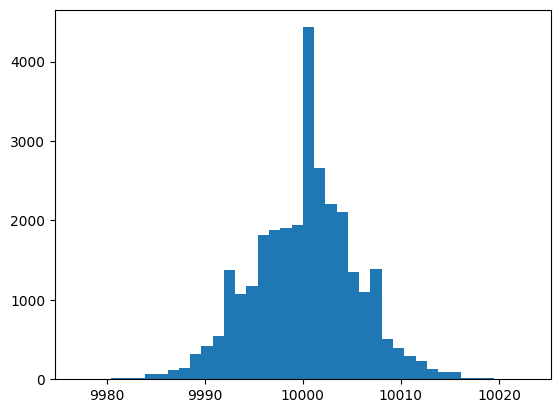

In [52]:
plt.hist(new_osmium, bins=40)

In [53]:
# Check osmium EMA reverting behavior
def ema_mp(mid_prices, alpha):
    mid_prices = np.array(mid_prices, dtype=float)
    ema = np.zeros_like(mid_prices)

    # Initialize EMA with first value
    ema[0] = mid_prices[0]

    # Compute EMA
    for i in range(1, len(mid_prices)):
        ema[i] = alpha * mid_prices[i] + (1 - alpha) * ema[i-1]

    # Return EMA - midprice (you can flip sign if needed)
    return ema - mid_prices

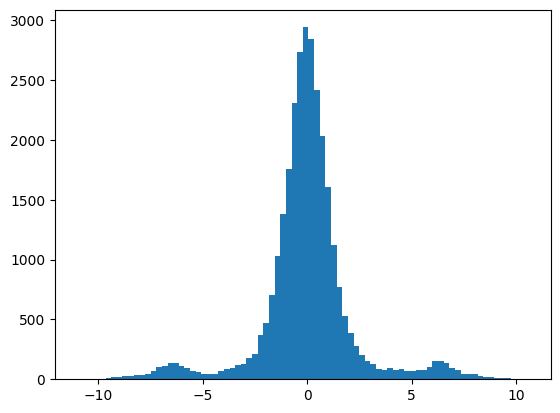

In [59]:
plt.hist(ema_mp(new_osmium,0.2), bins = 80)
plt.show()

In [66]:

mid = np.array(new_osmium)
signal = ema_mp(new_osmium, 0.2)
H = 10


dmid = mid[H:] - mid[:-H]
sig  = signal[:-H]

nbins = 50

edges = np.quantile(sig, np.linspace(0, 1, nbins + 1))

idx = np.digitize(sig, edges) - 1

g = np.zeros(nbins)
for b in range(nbins):
    mask = idx == b
    g[b] = dmid[mask].mean() if np.any(mask) else np.nan


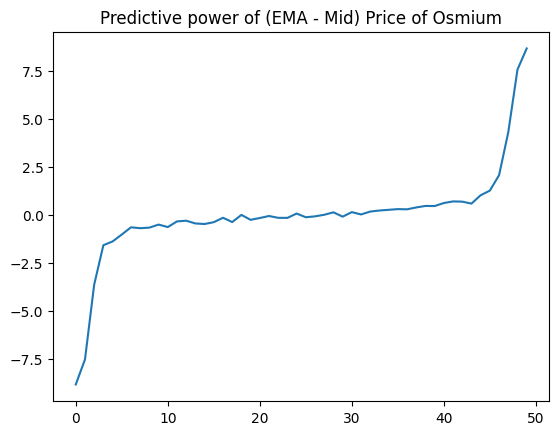

In [67]:
plt.plot(g)
plt.title("Predictive power of (EMA - Mid) Price of Osmium")
plt.show()

In [88]:
# pepper research

new_pepper = []
for i in pepper_mid_price:
    if i > 0:
        new_pepper.append(i)

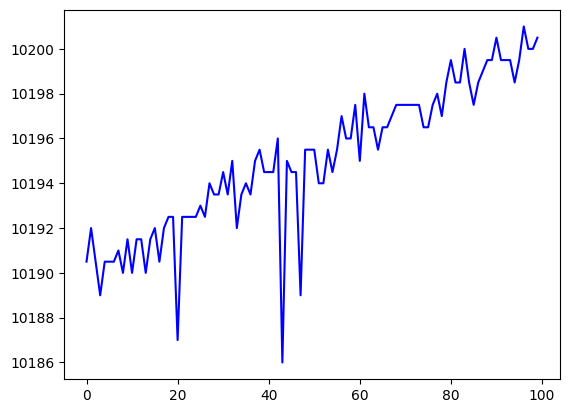

In [91]:
plt.plot(new_pepper[1900:2000], color="blue", label="Fair Price")

In [240]:
(pepper_ask_price - pepper_bid_price).mean()

np.float64(37.67496666666667)

In [ ]:
import json
from datamodel import OrderDepth, TradingState, Order
from typing import Dict, List


class UserTrader(Trader):
    def __init__(self):
        self.alpha = 0.2  # EMA SMOOTH
        self.ema_root = None  # EMA state
        
    def get_weighted_liquidity(self, state: TradingState, symbol: str):
        weighted_bid = 0
        weighted_ask = 0

        volume_sum_bids = 0
        volume_sum_asks = 0

        for price in state.order_depths[symbol].buy_orders:
            weighted_bid += (price * state.order_depths[symbol].buy_orders[price])
            volume_sum_bids += state.order_depths[symbol].buy_orders[price]

        for price in state.order_depths[symbol].sell_orders:
            weighted_ask += (price * abs(state.order_depths[symbol].sell_orders[price]))
            volume_sum_asks += abs(state.order_depths[symbol].sell_orders[price])

        weighted_bid /= volume_sum_bids
        weighted_ask /= volume_sum_asks
        
        return (weighted_bid + weighted_ask) / 2


    def trade_pepper_root(self, state: TradingState):
        symbol_name: str = "INTARIAN_PEPPER_ROOT"
        target_inventory =70
        LIMIT = 80
        position = state.position.get(symbol_name, 0)
        inventory_error = position-target_inventory
        base_size=10
        if len(state.order_depths[symbol_name].buy_orders) == 0 or len(state.order_depths[symbol_name].sell_orders) == 0:
            return
        

        best_bid = max(state.order_depths[symbol_name].buy_orders)
        best_ask = min(state.order_depths[symbol_name].sell_orders)
        #BUY & HOLD STRAT
        self.result[symbol_name].append(
                Order(symbol_name, best_ask,LIMIT-position)
        )
        return
      
        mp = int((best_bid + best_ask) / 2)

        self.update_ema(state, mp)

        
        
        shift = (mp - self.ema_root) * 0.3
        clamp_shift = max(-2, min(2, int(shift)))
        bid_quote = int(best_bid + 1 + clamp_shift)
        ask_quote = int(best_ask - 1 + clamp_shift)
        spread = ask_quote-bid_quote
        if bid_quote < mp and ask_quote > mp:
            self.result[symbol_name].append(
                Order(symbol_name, bid_quote, max(0, min(LIMIT - position, base_size - inventory_error)))
            )
            if spread >= 10:
                self.result[symbol_name].append(
                    Order(symbol_name, ask_quote, -max(0, min(LIMIT + position, base_size+inventory_error)))
                )

    def update_ema(self, state: TradingState, mp):
        if self.ema_root is None:
            self.ema_root = mp
        else:
            self.ema_root = self.alpha * mp + (1 - self.alpha) * self.ema_root
    def trade_ash_coated_osmium(self, state: TradingState):
        symbol_name: str = "ASH_COATED_OSMIUM"
        LIMIT = 50
        position = state.position.get(symbol_name, 0)
        
        if len(state.order_depths[symbol_name].buy_orders) == 0 or len(state.order_depths[symbol_name].sell_orders) == 0:
            return

        best_bid = max(state.order_depths[symbol_name].buy_orders)
        best_ask = min(state.order_depths[symbol_name].sell_orders)
        mid_price = int((best_bid + best_ask) / 2)
        
        
        if position >= LIMIT: # flatten position to 0
           self.result[symbol_name].append(Order(symbol_name, mid_price, -state.position[symbol_name]))
           return
        elif position <= -LIMIT: # flatten position to 0
           self.result[symbol_name].append(Order(symbol_name, mid_price, abs(state.position[symbol_name])))
           return 
       
        bid_quote = best_bid + 1
        ask_quote = best_ask - 1
    
        if bid_quote < mid_price and ask_quote > mid_price:
            self.result[symbol_name].append(
                Order(symbol_name, bid_quote, min(LIMIT - (position), int(((mid_price - bid_quote) / 3) * 10)))
            )
            self.result[symbol_name].append(
                Order(symbol_name, ask_quote, max(-LIMIT - (position), -int(((ask_quote - mid_price) / 3) * 10)))
            )
        


    def run(self, state: TradingState):
        self.result = {}

        self.result["ASH_COATED_OSMIUM"] = []
        self.result["INTARIAN_PEPPER_ROOT"] = []

        # --- LOAD STATE ---
        if state.traderData:
            try:
                data = json.loads(state.traderData)
                self.ema_root = data.get("ema_root", None)
            except:
                self.ema_root = None

        # --- EXECUTE STRATEGY ---

        self.trade_pepper_root(state)
        self.trade_ash_coated_osmium(state)

        # --- SAVE STATE ---
        traderData = json.dumps({
            "ema_root": self.ema_root
        })

        return self.result, 0, traderData

In [3]:
prices_files = []
trades_files = []
round = 1
for i in range(-2, 1):
    prices_files.append("./data/round_1_data/prices_round_"+str(round)+"_day_"+str(i)+".csv")
    trades_files.append("./data/round_1_data/trades_round_"+str(round)+"_day_"+str(i)+".csv")
backtesting_engine = Backtester(prices_files, trades_files)

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("", 0)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Project

In [41]:
sample_trader = UserTrader()
#backtesting_engine.custom_shifter["TOMATOES"]=1.5
backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=False, enable_market_trades=True)

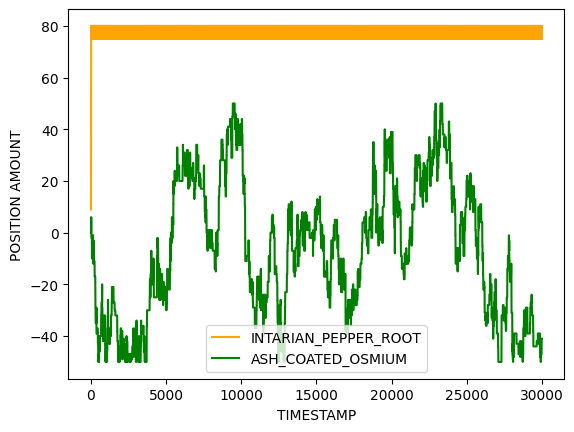

In [42]:
backtesting_result.graph_inventory()

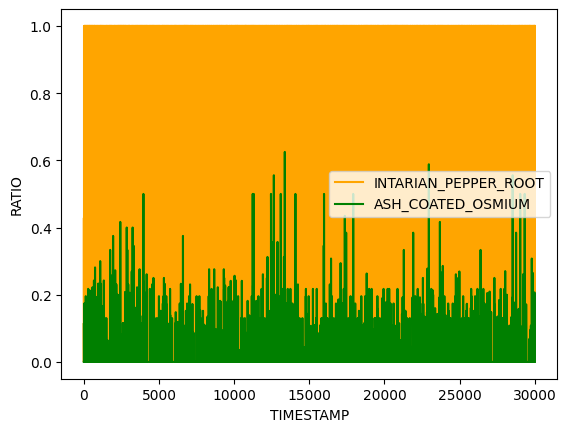

In [43]:
backtesting_result.graph_fill_ratios()

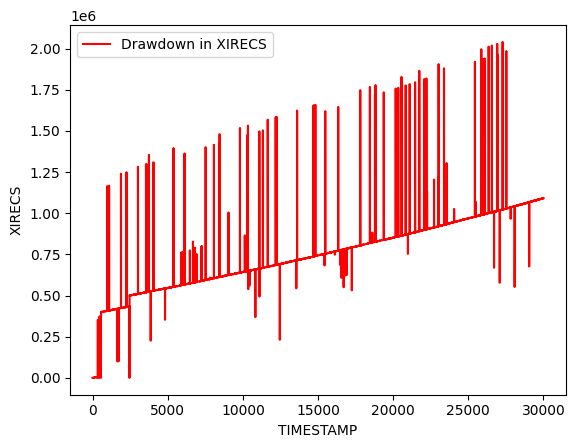

In [44]:
backtesting_result.graph_drawdown()

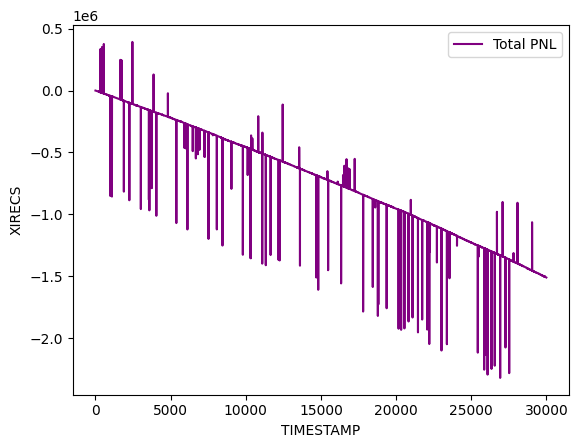

In [39]:
backtesting_result.graph_pnl()

In [59]:
import math

total_runs = 1
all_end_pnl=[]
all_sharpe=[]
for i in range(total_runs):
    backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=True)
    t_sum = 0
    total_pnl_series=[]
    for symbol in backtesting_engine.symbols:
        t_sum+=backtesting_result.pnl_realized[len(backtesting_result.pnl_realized)-1][symbol]
        t_sum+=backtesting_result.pnl_unrealized[len(backtesting_result.pnl_realized)-1][symbol]

    for t in range(len(backtesting_result.pnl_realized)):
        s=0
        for symbol in backtesting_engine.symbols:
            s+=backtesting_result.pnl_realized[t][symbol]
            s+=backtesting_result.pnl_unrealized[t][symbol]
        total_pnl_series.append(s)

    returns = np.diff(total_pnl_series)
    mean_ret = returns.mean()
    std_ret = returns.std()
    all_sharpe.append((mean_ret/std_ret)*math.sqrt(len(backtesting_result.pnl_realized)))
    all_end_pnl.append(t_sum)



In [60]:
all_sharpe

[np.float64(0.017148443377576213)]

(array([  5.,   0.,   0.,   0.,   0.,  97., 111., 211.,  37.,  39.]),
 array([ 622. , 1528.6, 2435.2, 3341.8, 4248.4, 5155. , 6061.6, 6968.2,
        7874.8, 8781.4, 9688. ]),
 <BarContainer object of 10 artists>)

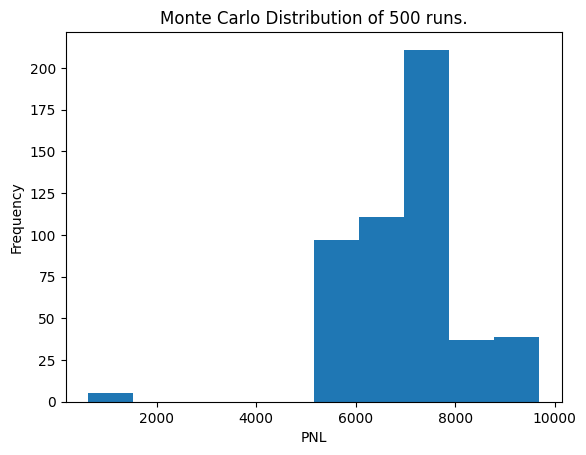

In [61]:
#plt.hist(all_sharpe, bins=10)
plt.title("Monte Carlo Distribution of " + str(total_runs) + " runs.")
plt.xlabel("PNL")
plt.ylabel("Frequency")
plt.hist(all_end_pnl, bins=10)

(array([  5.,   0.,   0.,   0.,  42., 162., 141.,  99.,  19.,  32.]),
 array([0.08036829, 0.23216623, 0.38396417, 0.53576212, 0.68756006,
        0.839358  , 0.99115595, 1.14295389, 1.29475184, 1.44654978,
        1.59834772]),
 <BarContainer object of 10 artists>)

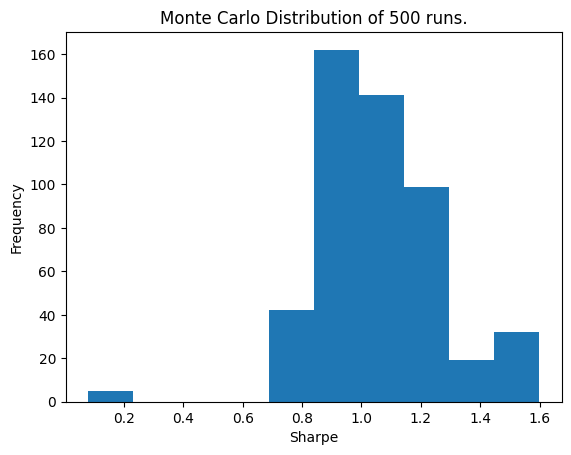

In [62]:
plt.title("Monte Carlo Distribution of " + str(total_runs) + " runs.")
plt.xlabel("Sharpe")
plt.ylabel("Frequency")
plt.hist(all_sharpe, bins=10)

In [63]:
# Print montecarlo sim stats
a_s = np.array(all_sharpe)
print ("Mean Sharpe: " + str(a_s.mean()))
print ("STD Sharpe: " + str(a_s.std()))

standard_error_sharpe = a_s.mean()/math.sqrt(len(all_sharpe))
target_z_score = 1.96

print ("95% Confidence that sharpe is between " + str(a_s.mean() - standard_error_sharpe*target_z_score) + " and " + str(a_s.mean() + standard_error_sharpe*target_z_score))

a_p = np.array(all_end_pnl)
print ("Mean PNL: " + str(a_p.mean()))
print ("STD PNL: " + str(a_p.std()))

standard_error_pnl = a_p.mean()/math.sqrt(len(all_end_pnl))
print ("95% Confidence that PNL is between " + str(a_p.mean() - standard_error_pnl*target_z_score) + " and " + str(a_p.mean() + standard_error_pnl*target_z_score))

Mean Sharpe: 1.0654293556997703
STD Sharpe: 0.2090352682317448
95% Confidence that sharpe is between 0.9720403550886855 and 1.158818356310855
Mean PNL: 6933.282
STD PNL: 1184.0408871639527
95% Confidence that PNL is between 6325.5530375203125 and 7541.010962479688
